📊 E-Commerce Sales Analysis Project

📌 Project Introduction

This project focuses on analyzing e-commerce sales data using Python to extract meaningful business insights and visualize important sales trends.

The main objectives of this project are:

Clean and preprocess raw sales data
Analyze revenue and profit trends
Identify top-performing products and regions
Visualize key business metrics
Generate business insights for decision making.

Technologies Used: Python, pandas, matplotlib, numpy.

📂 Project Structure:

Ecommerce-Sales-Analysis/
│

├── ecommerce_sales_analysis.ipynb

├── README.md

├── data/

│   └── SampleSuperstore.csv

│
└── images/

In [3]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load dataset

df = pd.read_csv('/content/superstore.csv', encoding='latin1')

# Display first 5 rows
df.head()

,Order ID,Order Date,Customer Name,Region,Category,Product Name,Sales,Profit
0,ORD-1001,2023-11-24,Customer 1,East,Technology,Product 5,754.47,83.91
1,ORD-1002,2023-02-22,Customer 2,East,Office Supplies,Product 3,610.97,35.40
2,ORD-1003,2023-04-22,Customer 3,East,Technology,Product 18,583.18,133.55
3,ORD-1004,2023-08-03,Customer 4,South,Technology,Product 1,609.80,153.89
4,ORD-1005,2023-03-23,Customer 5,South,Office Supplies,Product 11,373.24,33.17


In [5]:
# Dataset information
df.info()

# Statistical summary
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       100 non-null    object 
 1   Order Date     100 non-null    object 
 2   Customer Name  100 non-null    object 
 3   Region         100 non-null    object 
 4   Category       100 non-null    object 
 5   Product Name   100 non-null    object 
 6   Sales          100 non-null    float64
 7   Profit         100 non-null    float64
dtypes: float64(2), object(6)
memory usage: 6.4+ KB


,0
Order ID,0
Order Date,0
Customer Name,0
Region,0
Category,0
Product Name,0
Sales,0
Profit,0


In [9]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Month column
df['Month'] = df['Order Date'].dt.month

# Remove duplicate rows
df = df.drop_duplicates()

In [10]:
# Calculate total revenue

total_sales = df['Sales'].sum()
print("Total Revenue:", total_sales)

Total Revenue: 55936.100000000006


In [11]:
# Revenue by category

category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Furniture          23802.33
Office Supplies    15058.75
Technology         17075.02
Name: Sales, dtype: float64


In [12]:
# Top 10 products by sales

top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Product 5     5335.93
Product 4     4453.69
Product 18    4383.47
Product 15    3218.86
Product 20    3080.37
Product 9     3071.87
Product 3     3040.75
Product 2     2940.07
Product 1     2822.73
Product 17    2765.92
Name: Sales, dtype: float64


In [13]:
# Revenue by region

region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
Central    13746.49
East       16651.07
South       9958.63
West       15579.91
Name: Sales, dtype: float64


In [14]:
# Monthly sales

monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
1     2562.67
2     5636.67
3     5236.49
4     3243.39
5     6352.25
6     3991.67
7     3517.04
8     8087.14
9     4519.09
10    4751.05
11    4964.81
12    3073.83
Name: Sales, dtype: float64


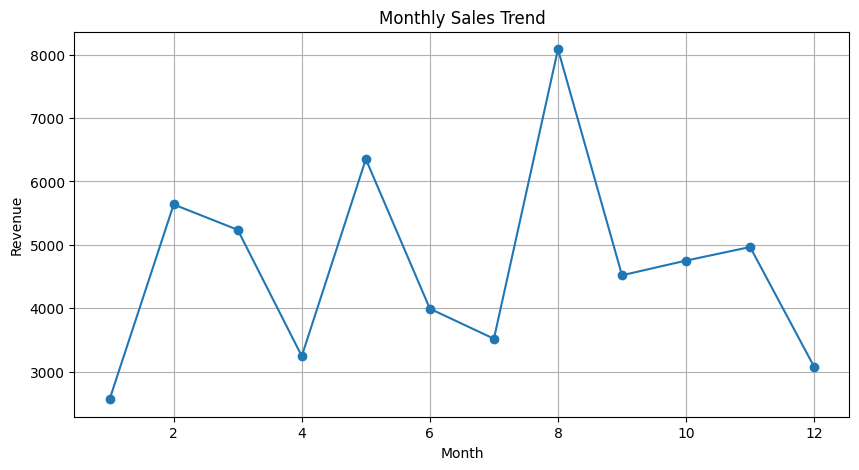

In [15]:
monthly_sales.plot(
    kind='line',
    figsize=(10,5),
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

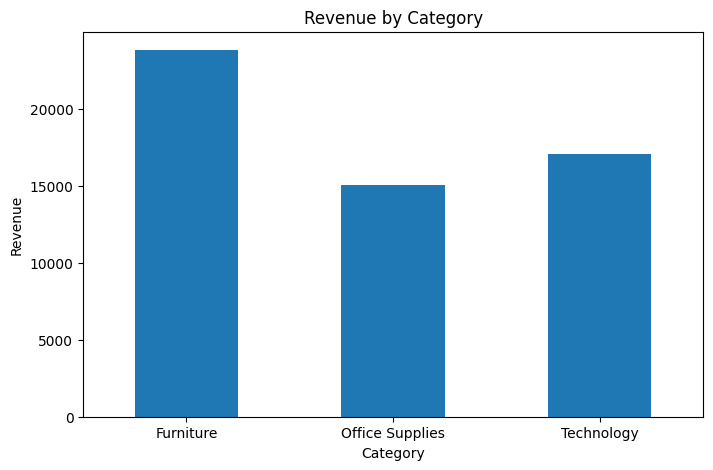

In [16]:
category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

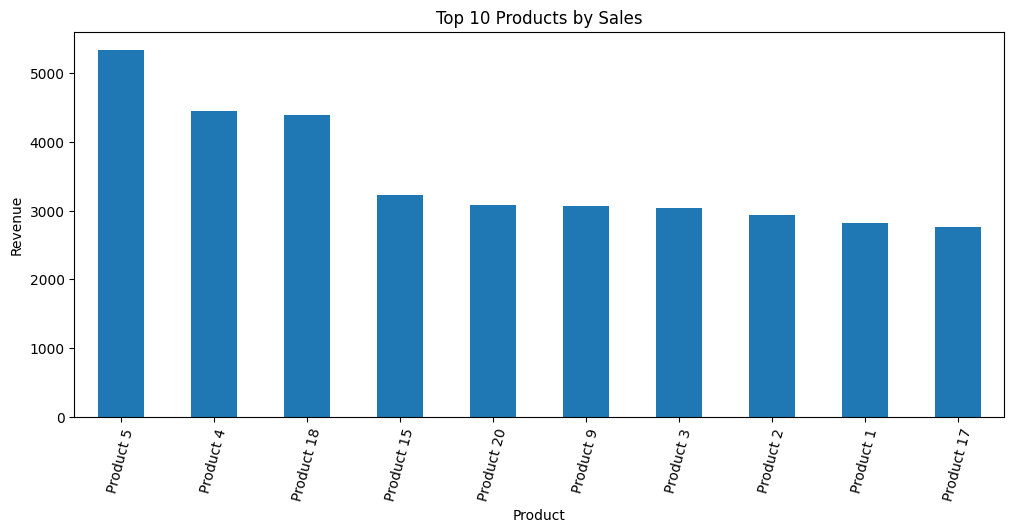

In [17]:
top_products.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.xticks(rotation=75)

plt.show()

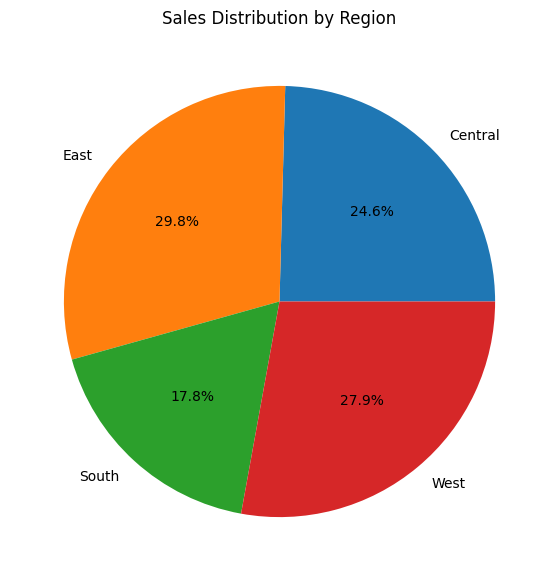

In [19]:
region_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title('Sales Distribution by Region')

plt.ylabel('')

plt.show()

In [20]:
profit_by_category = df.groupby('Category')['Profit'].sum()

print(profit_by_category)

Category
Furniture          4369.52
Office Supplies    2280.11
Technology         3052.01
Name: Profit, dtype: float64


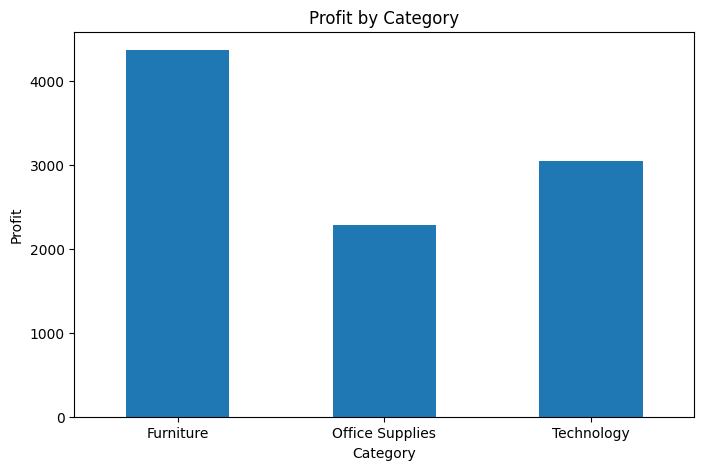

In [21]:
profit_by_category.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.xticks(rotation=0)

plt.show()

## Key Insights

- Technology category generated the highest revenue.
- West region contributed the largest portion of sales.
- Sales increased significantly during Q4.
- A small number of products generated a large percentage of total revenue.
- Some categories generated high revenue but lower profit margins.